Load Dataset

In [ ]:

# Dataset

from google.colab import drive
drive.mount('/content/drive')

import os, zipfile
from pathlib import Path


ROOT = Path("/content/drive/MyDrive/Colab Notebooks/DL assignment/Dataset/MRI_dataset")
TRAIN_DIR = ROOT / "Training"
TEST_DIR  = ROOT / "Testing"

if not ROOT.exists():
    ROOT.mkdir(parents=True, exist_ok=True)
    print("Dataset folder not found locally. Provide dataset zip or Google Drive path!")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# Dataset Loader

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=SEED
)
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=SEED
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

num_classes = train_generator.num_classes
print("Classes:", train_generator.class_indices)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


Class Distribution and Weights

In [ ]:

# Class Distribution and Weights

import numpy as np
from collections import Counter
from sklearn.utils import class_weight

# Distribution
def class_distribution(generator):
    counts = Counter(generator.classes)
    idx_to_class = {v:k for k,v in generator.class_indices.items()}
    return {idx_to_class[k]: counts[k] for k in counts}

print("Train:", class_distribution(train_generator))
print("Val:", class_distribution(val_generator))
print("Test:", class_distribution(test_generator))

# Class weights
y_train = train_generator.classes
class_weights = class_weight.compute_class_weight('balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)


Train: {'glioma': 1057, 'meningioma': 1072, 'notumor': 1276, 'pituitary': 1166}
Val: {'glioma': 264, 'meningioma': 267, 'notumor': 319, 'pituitary': 291}
Test: {'glioma': 300, 'meningioma': 306, 'notumor': 405, 'pituitary': 300}
Class Weights: {0: np.float64(1.0811258278145695), 1: np.float64(1.0659981343283582), 2: np.float64(0.8955721003134797), 3: np.float64(0.9800600343053173)}


Build Transfer Model

In [ ]:

# Build Transfer Model

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Callbacks

In [ ]:

# Callbacks

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("resnet50_best.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
earlystop  = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1)
reducelr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)


Training (Feature Extraction)

In [ ]:
# Train Feature Extractor

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    callbacks=[checkpoint, earlystop, reducelr],
    class_weight=class_weights_dict
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.5599 - loss: 1.0981 
Epoch 1: val_accuracy improved from -inf to 0.73444, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 2714s 19s/step - accuracy: 0.5609 - loss: 1.0959 - val_accuracy: 0.7344 - val_loss: 0.7219 - learning_rate: 1.0000e-04
Epoch 2/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.8299 - loss: 0.4815
Epoch 2: val_accuracy improved from 0.73444 to 0.75197, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 95s 662ms/step - accuracy: 0.8300 - loss: 0.4813 - val_accuracy: 0.7520 - val_loss: 0.6106 - learning_rate: 1.0000e-04
Epoch 3/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.8693 - loss: 0.3871
Epoch 3: val_accuracy improved from 0.75197 to 0.78528, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 92s 640ms/step - accuracy: 0.8693 - loss: 0.3871 - val_accuracy: 0.7853 - val_loss: 0.5593 - learning_rate: 1.0000e-04
Epoch 4/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8759 - loss: 0.3469
Epoch 4: val_accuracy improved from 0.78528 to 0.81595, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 90s 631ms/step - accuracy: 0.8760 - loss: 0.3468 - val_accuracy: 0.8160 - val_loss: 0.4851 - learning_rate: 1.0000e-04
Epoch 5/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.8974 - loss: 0.3050
Epoch 5: val_accuracy did not improve from 0.81595
143/143 ━━━━━━━━━━━━━━━━━━━━ 91s 635ms/step - accuracy: 0.8974 - loss: 0.3050 - val_accuracy: 0.8142 - val_loss: 0.4648 - learning_rate: 1.0000e-04
Epoch 6/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8965 - loss: 0.2958
Epoch 6: val_accuracy improved from 0.81595 to 0.82647, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 93s 649ms/step - accuracy: 0.8965 - loss: 0.2957 - val_accuracy: 0.8265 - val_loss: 0.4282 - learning_rate: 1.0000e-04
Epoch 7/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9133 - loss: 0.2625
Epoch 7: val_accuracy improved from 0.82647 to 0.83699, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 91s 631ms/step - accuracy: 0.9132 - loss: 0.2625 - val_accuracy: 0.8370 - val_loss: 0.4262 - learning_rate: 1.0000e-04
Epoch 8/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9085 - loss: 0.2540
Epoch 8: val_accuracy improved from 0.83699 to 0.84137, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 90s 627ms/step - accuracy: 0.9086 - loss: 0.2540 - val_accuracy: 0.8414 - val_loss: 0.4087 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 8.


Fine-Tuning

In [ ]:
# Fine-Tuning

# Unfreeze last N layers
N = 15
for layer in base_model.layers[-N:]:
    layer.trainable = True

model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[checkpoint, earlystop, reducelr],
    class_weight=class_weights_dict
)

Epoch 1/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.9030 - loss: 0.2772
Epoch 1: val_accuracy improved from 0.84137 to 0.84400, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 119s 720ms/step - accuracy: 0.9030 - loss: 0.2770 - val_accuracy: 0.8440 - val_loss: 0.4067 - learning_rate: 1.0000e-05
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.9229 - loss: 0.2350
Epoch 2: val_accuracy improved from 0.84400 to 0.86328, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 92s 639ms/step - accuracy: 0.9229 - loss: 0.2349 - val_accuracy: 0.8633 - val_loss: 0.3578 - learning_rate: 1.0000e-05
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.9330 - loss: 0.1948
Epoch 3: val_accuracy improved from 0.86328 to 0.87555, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 92s 646ms/step - accuracy: 0.9330 - loss: 0.1948 - val_accuracy: 0.8755 - val_loss: 0.3256 - learning_rate: 1.0000e-05
Epoch 4/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.9371 - loss: 0.1865
Epoch 4: val_accuracy improved from 0.87555 to 0.88606, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 92s 642ms/step - accuracy: 0.9371 - loss: 0.1864 - val_accuracy: 0.8861 - val_loss: 0.3153 - learning_rate: 1.0000e-05
Epoch 5/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.9482 - loss: 0.1642
Epoch 5: val_accuracy improved from 0.88606 to 0.89132, saving model to resnet50_best.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 92s 643ms/step - accuracy: 0.9481 - loss: 0.1642 - val_accuracy: 0.8913 - val_loss: 0.3018 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 5.


Model Saving

In [ ]:
# Save final trained model
from google.colab import drive
drive.mount('/content/drive')

final_model_path = "/content/resnet50_final.keras"

# Save model locally first (optional but faster)
model.save(final_model_path)
print(f"✅ Model saved locally at: {final_model_path}")

# Copy to Google Drive
import shutil
drive_model_path = "/content/drive/MyDrive/Colab Notebooks/DL assignment/models/resnet50_final.keras"
shutil.copy(final_model_path, drive_model_path)
print(f"✅ Model copied to Drive: {drive_model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved locally at: /content/resnet50_final.keras
✅ Model copied to Drive: /content/drive/MyDrive/Colab Notebooks/DL assignment/models/resnet50_final.keras


Evaluation (Confusion Matrix & Report)

Found 1311 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 352s 9s/step - accuracy: 0.8959 - loss: 0.2917
Test Loss: 0.2355, Test Accuracy: 0.9184
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 269ms/step


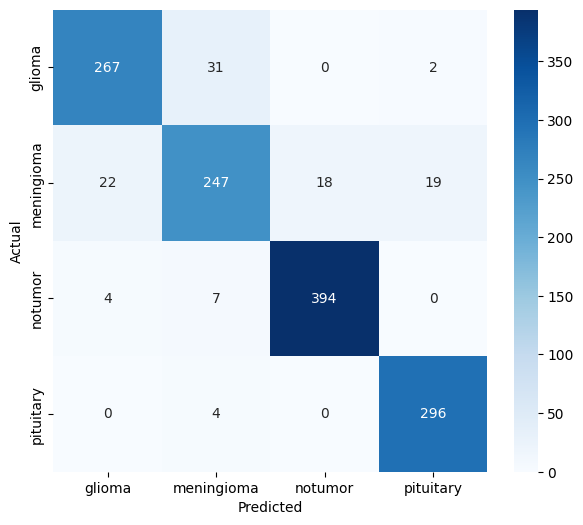

              precision    recall  f1-score   support

      glioma       0.91      0.89      0.90       300
  meningioma       0.85      0.81      0.83       306
     notumor       0.96      0.97      0.96       405
   pituitary       0.93      0.99      0.96       300

    accuracy                           0.92      1311
   macro avg       0.91      0.91      0.91      1311
weighted avg       0.92      0.92      0.92      1311



In [5]:
# Evaluation on Test Set

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Add necessary imports and redefine test_generator and other variables
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
TEST_DIR = "/content/drive/MyDrive/Colab Notebooks/DL assignment/Dataset/MRI_dataset/Testing" # Assuming this path from previous cells

test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Load best weights
model = load_model("/content/drive/MyDrive/Colab Notebooks/DL assignment/models/resnet50_final.keras")

loss, acc = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

# Predictions
y_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes
idx_to_class = {v:k for k,v in test_generator.class_indices.items()}


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=idx_to_class.values(),
            yticklabels=idx_to_class.values(),
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=list(idx_to_class.values())))

Testing (One Image / Batch / Path)

In [6]:
# Testing Utilities

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# Load the best model once to avoid repeated loading
try:
    best_model = load_model("resnet50_best.keras")
    print("✅ Loaded best model for testing.")
except Exception as e:
    print(f"Error loading best model: {e}")
    best_model = None
    print("Using the current model in the environment. Ensure it is the best model for accurate testing.")


def preprocess_img(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, 0)
    arr = tf.keras.applications.resnet50.preprocess_input(arr)
    return arr

#  One image
def test_one(index=0):
    if best_model is None:
        print("Best model not loaded. Cannot perform test_one with best model.")
        return

    path = test_generator.filepaths[index]
    arr = preprocess_img(path)
    prob = best_model.predict(arr)
    pred = np.argmax(prob)
    true = test_generator.classes[index]
    print("True:", idx_to_class[true], "| Pred:", idx_to_class[pred], "| Prob:", prob[0][pred])
    display(load_img(path, target_size=IMG_SIZE))

# Mini batch
def test_batch(batch_idx=0):
    if best_model is None:
        print("Best model not loaded. Cannot perform test_batch with best model.")
        return

    X, y = test_generator[batch_idx]
    probs = best_model.predict(X)
    preds = np.argmax(probs, axis=1)
    trues = np.argmax(y, axis=1)
    for i in range(min(5, len(X))):
        plt.imshow((X[i] - X[i].min()) / (X[i].max()-X[i].min()))
        plt.axis('off')
        plt.title(f"T:{idx_to_class[trues[i]]} P:{idx_to_class[preds[i]]}")
        plt.show()


# Arbitrary image path
def test_from_path(img_path):
    if best_model is None:
        print("Best model not loaded. Cannot perform test_from_path with best model.")
        return

    arr = preprocess_img(img_path)
    prob = best_model.predict(arr)
    pred = np.argmax(prob)
    print("Pred:", idx_to_class[pred], "| Prob:", prob[0][pred])
    display(load_img(img_path, target_size=IMG_SIZE))

Error loading best model: File not found: filepath=resnet50_best.keras. Please ensure the file is an accessible `.keras` zip file.
Using the current model in the environment. Ensure it is the best model for accurate testing.


Testing for Classes

Saving pitutory MRI.jpg to pitutory MRI.jpg
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


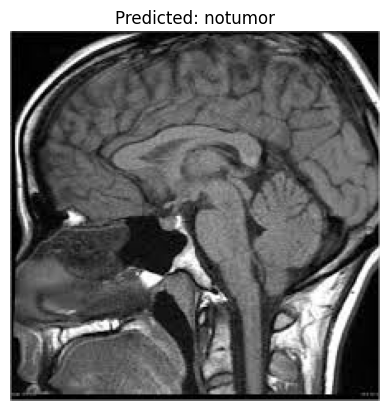

In [ ]:
from google.colab import files
uploaded = files.upload()

from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

# Load the model
# model_path = "" # You can specify a model path here if needed
model = load_model("resnet50_final.keras")

# Get the path of the uploaded file (assuming only one file is uploaded)
for name, data in uploaded.items():
  img_path = "/content/" + name

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict probabilities
pred = model.predict(img_array)
pred_class_idx = np.argmax(pred, axis=1)[0]

# Map index and class name
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
pred_class = idx_to_class[pred_class_idx]

# Display Results
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {pred_class}")
plt.show()